### from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

In [69]:
import olefile
import xmltodict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
%matplotlib inline

## Read Methods File

In [2]:
!pwd

/Users/eileen.wang/Desktop/diann/code


In [3]:
meth_file = olefile.OleFileIO('/Users/eileen.wang/Desktop/diann/SampleData/methods/LC/10m150nlRainmanA15-75.meth')
meth_file

In [44]:
%load_ext autoreload
%autoreload 2

from lc_method_parser import LCMethod

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
# Parse method txt
text = meth_file.openstream(['SiiXcalibur', 'Text']).read().decode('utf-16')
method = LCMethod(text)

In [67]:
text.split('\r\n')

['---- Overview ----',
 'Name: New Instrument Method',
 'Comment: ',
 'Run time: 12.375 [min]',
 'Instrument: VanquishNeo1 on tims-scp-00014',
 'Description: ',
 '---- Script ----',
 'initial     Instrument Setup',
 '            Neo.SamplerModule.Sampler.LoadingVolume: Automatic',
 '            Neo.SamplerModule.Sampler.FastLoadingWanted: Yes',
 '            Neo.SamplerModule.Sampler.KeepLoopInline: No',
 '            Neo.SamplerModule.Sampler.DirectLoadingMode: PressureControl',
 '            Neo.SamplerModule.Sampler.DirectLoadingPressure: 1500.0 [bar]',
 '            Neo.SamplerModule.Sampler.TrapZebraWashCycles: 4',
 '            Neo.SamplerModule.Sampler.TrapZebraWashWanted: No',
 '            Neo.PumpModule.Pump.FastColumnEquilibrationWanted: Yes',
 '            Neo.PumpModule.Pump.ColumnEquilibrationFactor: 3.0',
 '            Neo.PumpModule.Pump.ColumnEquilibrationMode: PressureControl',
 '            Neo.PumpModule.Pump.ColumnEquilibrationPressure: 1500.0 [bar]',
 '           

In [ ]:
lines = text.split('\r\n')
sections = {}
current_section = None
time = None
for line in lines:
    ## check if line is indented, if it it, then it is part of an exisitng section
    if line.startswith(' '):       
        key_value_pair = re.search(': ', line)
        if key_value_pair:
            key, value = line.split(': ', 1)
            if value != '':
                if current_section:
                    if current_section == 'Gradient':
                        sections[current_section][key][current_section][time] = {key: value.strip()}
                    elif sections.keys().__contains__(current_section):
                        sections[current_section][key] = value.strip()

                    else:  
                        sections[current_section] = {key: value.strip()}

    # if not indented, it is either the start of a new section or a key value pair
    else:
        key_value_pair = re.search(': ', line)
        if key_value_pair:
            key, value = line.split(': ', 1)
            if value != '':
                sections[key.strip()] = value.strip()
            current_section = None

        # if Run/gradient section has started and line does not contain 'Stop Run', continue putting gradient details
        elif current_section == 'Gradient' and not re.search('Stop Run', line):
            continue
        # If new section, indicate current section
        else:
            current_section = line.strip()
            if current_section == '0.000 [min] Run':
                current_section = 'Gradient'
                sections[current_section][key][current_section] = {}

In [104]:
sections

{'Name': 'New Instrument Method',
 'Run time': '12.375 [min]',
 'Instrument': 'VanquishNeo1 on tims-scp-00014',
 'initial     Instrument Setup': {'            Neo.SamplerModule.Sampler.LoadingVolume': 'Automatic',
  '            Neo.SamplerModule.Sampler.FastLoadingWanted': 'Yes',
  '            Neo.SamplerModule.Sampler.KeepLoopInline': 'No',
  '            Neo.SamplerModule.Sampler.DirectLoadingMode': 'PressureControl',
  '            Neo.SamplerModule.Sampler.DirectLoadingPressure': '1500.0 [bar]',
  '            Neo.SamplerModule.Sampler.TrapZebraWashCycles': '4',
  '            Neo.SamplerModule.Sampler.TrapZebraWashWanted': 'No',
  '            Neo.PumpModule.Pump.FastColumnEquilibrationWanted': 'Yes',
  '            Neo.PumpModule.Pump.ColumnEquilibrationFactor': '3.0',
  '            Neo.PumpModule.Pump.ColumnEquilibrationMode': 'PressureControl',
  '            Neo.PumpModule.Pump.ColumnEquilibrationPressure': '1500.0 [bar]',
  '            Neo.PumpModule.Pump.TandemWashType':

In [83]:
sections.keys()

dict_keys(['---- Overview ----', 'Name: New Instrument Method', 'Comment:', 'Run time: 12.375 [min]', 'Instrument: VanquishNeo1 on tims-scp-00014', 'Description:', '---- Script ----', 'initial     Instrument Setup', '0.000 [min] Equilibration', '0.000 [min] Inject Preparation', '0.000 [min] Inject', '0.000 [min] Start Run', '0.000 [min] Run', '0.500 [min]', '1.500 [min]', '5.500 [min]', '8.000 [min]', '10.000 [min]', '11.000 [min]', '12.000 [min]', '12.125 [min]', '12.375 [min]', '12.375 [min] Stop Run', '12.375 [min] Post Run'])

In [76]:
# Access parameters
pump_curve = method.get_param('Neo.PumpModule.Pump.Curve')

In [56]:
meth_file.openstream(['SiiXcalibur', 'Text']).read().decode('utf-16')

'---- Overview ----\r\nName: New Instrument Method\r\nComment: \r\nRun time: 12.375 [min]\r\nInstrument: VanquishNeo1 on tims-scp-00014\r\nDescription: \r\n---- Script ----\r\ninitial     Instrument Setup\r\n            Neo.SamplerModule.Sampler.LoadingVolume: Automatic\r\n            Neo.SamplerModule.Sampler.FastLoadingWanted: Yes\r\n            Neo.SamplerModule.Sampler.KeepLoopInline: No\r\n            Neo.SamplerModule.Sampler.DirectLoadingMode: PressureControl\r\n            Neo.SamplerModule.Sampler.DirectLoadingPressure: 1500.0 [bar]\r\n            Neo.SamplerModule.Sampler.TrapZebraWashCycles: 4\r\n            Neo.SamplerModule.Sampler.TrapZebraWashWanted: No\r\n            Neo.PumpModule.Pump.FastColumnEquilibrationWanted: Yes\r\n            Neo.PumpModule.Pump.ColumnEquilibrationFactor: 3.0\r\n            Neo.PumpModule.Pump.ColumnEquilibrationMode: PressureControl\r\n            Neo.PumpModule.Pump.ColumnEquilibrationPressure: 1500.0 [bar]\r\n            Neo.PumpModule.Pump

In [54]:
method_streams

NameError: name 'method_streams' is not defined

In [ ]:

# Access gradient table as DataFrame
gradient_df = method.gradient
print(gradient_df)

# Get gradient at specific time (with interpolation)
percent_b_at_15min = method.get_gradient_at_time(15.0, '%B')

# Get sections
pump_section = method.get_section('Pump:')

# Print summary
print(method.summary())

# Index gradient DataFrame
method.gradient.loc[0, 'Time']  # First time point
method.gradient['%B'].values     # All %B values

In [4]:
meth_file.listdir()

[['AuditData'],
 ['LCQ Header'],
 ['SiiXcalibur', 'Data'],
 ['SiiXcalibur', 'Text']]

In [6]:
print(meth_file.openstream(['SiiXcalibur', 'Text']).read().decode('utf-16'))

---- Overview ----
Name: New Instrument Method
Comment: 
Run time: 12.375 [min]
Instrument: VanquishNeo1 on tims-scp-00014
Description: 
---- Script ----
initial     Instrument Setup
            Neo.SamplerModule.Sampler.LoadingVolume: Automatic
            Neo.SamplerModule.Sampler.FastLoadingWanted: Yes
            Neo.SamplerModule.Sampler.KeepLoopInline: No
            Neo.SamplerModule.Sampler.DirectLoadingMode: PressureControl
            Neo.SamplerModule.Sampler.DirectLoadingPressure: 1500.0 [bar]
            Neo.SamplerModule.Sampler.TrapZebraWashCycles: 4
            Neo.SamplerModule.Sampler.TrapZebraWashWanted: No
            Neo.PumpModule.Pump.FastColumnEquilibrationWanted: Yes
            Neo.PumpModule.Pump.ColumnEquilibrationFactor: 3.0
            Neo.PumpModule.Pump.ColumnEquilibrationMode: PressureControl
            Neo.PumpModule.Pump.ColumnEquilibrationPressure: 1500.0 [bar]
            Neo.PumpModule.Pump.TandemWashType: Trapezoidal
            Neo.PumpModule.Pu

## Extract LC Data

In [15]:
lc_data

'---- Overview ----\r\nName: New Instrument Method\r\nComment: \r\nRun time: 12.375 [min]\r\nInstrument: VanquishNeo1 on tims-scp-00014\r\nDescription: \r\n---- Script ----\r\ninitial     Instrument Setup\r\n            Neo.SamplerModule.Sampler.LoadingVolume: Automatic\r\n            Neo.SamplerModule.Sampler.FastLoadingWanted: Yes\r\n            Neo.SamplerModule.Sampler.KeepLoopInline: No\r\n            Neo.SamplerModule.Sampler.DirectLoadingMode: PressureControl\r\n            Neo.SamplerModule.Sampler.DirectLoadingPressure: 1500.0 [bar]\r\n            Neo.SamplerModule.Sampler.TrapZebraWashCycles: 4\r\n            Neo.SamplerModule.Sampler.TrapZebraWashWanted: No\r\n            Neo.PumpModule.Pump.FastColumnEquilibrationWanted: Yes\r\n            Neo.PumpModule.Pump.ColumnEquilibrationFactor: 3.0\r\n            Neo.PumpModule.Pump.ColumnEquilibrationMode: PressureControl\r\n            Neo.PumpModule.Pump.ColumnEquilibrationPressure: 1500.0 [bar]\r\n            Neo.PumpModule.Pump

In [14]:
lc_data = meth_file.openstream(['SiiXcalibur', 'Text']).read().decode('utf-16')
lc_data = lc_data[lc_data.index('<?xml'):]
lc_data


ValueError: substring not found

## Convert to a Python Dict

In [23]:
lc = xmltodict.parse(lc_data)
lc

OrderedDict([('owner', 'Thermo'),
             ('name', 'XCalibur Method'),
             ('description', 'XCalibur Method'),
             ('sampleLoadingFlow', '10'),
             ('sampleLoadingVolume', '2.5'),
             ('desaltingFlow', 'Not set'),
             ('desaltingVolume', '5'),
             ('desaltingMaxPressure', '950'),
             ('reEquilibrationPreColumnFlow', 'Not set'),
             ('reEquilibrationPreColumnVolume', '0'),
             ('reEquilibrationPreColumnMaxPressure', 'Not set'),
             ('reEquilibrationAnalyticalColumnFlow', 'Not set'),
             ('reEquilibrationAnalyticalColumnVolume', '4'),
             ('reEquilibrationAnalyticalColumnMaxPressure', '950'),
             ('washFlushVolume', 'Not set'),
             ('isWashCyclesEnabled', 'true'),
             ('washcycles',
              OrderedDict([('methodwashcycle',
                            [OrderedDict([('order', '0'),
                                          ('source', '1'),
      

## Calculate Gradient

In [57]:
gradient = pd.DataFrame(lc['gradients']['methodgradient'])
gradient = gradient.astype(int)
gradient.set_index('order', inplace=True)
gradient

,duration,flow,percentB
order,,,
0,0,300,5
1,5700,300,30
2,300,300,60
3,300,300,95
4,300,300,95
5,300,300,5
6,300,300,5


In [58]:
gradient['time'] = gradient['duration'].cumsum()
gradient['time (min)'] = gradient['time'] / 60
gradient

,duration,flow,percentB,time,time (min)
order,,,,,
0,0,300,5,0,0.0
1,5700,300,30,5700,95.0
2,300,300,60,6000,100.0
3,300,300,95,6300,105.0
4,300,300,95,6600,110.0
5,300,300,5,6900,115.0
6,300,300,5,7200,120.0


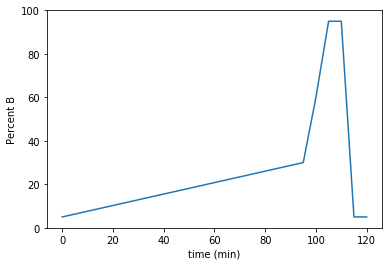

In [59]:
gradient.plot.line(x='time (min)', y='percentB', ylim=[0, 100], legend=False);
plt.ylabel('Percent B');

## Make Table of Other LC Settings (Volume, Flow Rate, and Max Pressure for each stage)

In [67]:
lcp = {key: val for key, val in lc.items() if not 'wash' in key and any(['Flow' in key, 'Volume' in key, 'MaxPressure' in key])}
lcp

{'sampleLoadingFlow': '10',
 'sampleLoadingVolume': '2.5',
 'desaltingFlow': 'Not set',
 'desaltingVolume': '5',
 'desaltingMaxPressure': '950',
 'reEquilibrationPreColumnFlow': 'Not set',
 'reEquilibrationPreColumnVolume': '0',
 'reEquilibrationPreColumnMaxPressure': 'Not set',
 'reEquilibrationAnalyticalColumnFlow': 'Not set',
 'reEquilibrationAnalyticalColumnVolume': '4',
 'reEquilibrationAnalyticalColumnMaxPressure': '950'}

In [71]:
prefixes = [key[:-4] for key in lcp if 'Flow' in key]
prefixes

['sampleLoading',
 'desalting',
 'reEquilibrationPreColumn',
 'reEquilibrationAnalyticalColumn']

In [111]:
data = []
for prefix in prefixes:
    dd = {'step': prefix}
    for value in ['Volume', 'Flow', 'MaxPressure']:
        try:
            dd[value] = lcp[prefix + value]
        except KeyError:
            pass
    data.append(dd)

df = pd.DataFrame(data)
df.set_index('step', inplace=True, )
df.replace('Not set', np.nan, inplace=True)
df = df.astype(float)
df.fillna('', inplace=True)

df

,Flow,MaxPressure,Volume
step,,,
sampleLoading,10,,2.5
desalting,,950,5.0
reEquilibrationPreColumn,,,0.0
reEquilibrationAnalyticalColumn,,950,4.0


## Make Table for Wash Cycles

In [88]:
df = pd.DataFrame(lc['washcycles']['methodwashcycle'])
df.set_index('order', inplace=True)
df

,source,volume,cycles
order,,,
0,1,20,2
1,3,20,2
